# 📚 Notebook 02 — Light Curve Preprocessing
## *Cleaning raw satellite data to expose hidden planetary signals*

---

**What you'll learn in this notebook:**
- Why raw data cannot be fed directly into ML models (sys/stellar trends)
- Normalisation: aligning different stars onto a common relative scale
- Robust statistics: why the **Median** beats the **Mean** for outlier removal
- Sigma-clipping: removing cosmic rays and spacecraft jitter
- Savitzky-Golay filtering: detrending slow stellar rotation and instrument drift
- Phase-folding: stacking periodic transits to boost the signal-to-noise ratio (SNR)

**Prerequisites:** Run notebook `01_download_data.ipynb` first!


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: Import packages and custom modules
# ============================================================
import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

plt.style.use('dark_background')

# Import our custom preprocessing functions
from src.preprocess import (
    load_fits, apply_quality_mask, sigma_clip,
    detrend_savgol, normalise, preprocess_lightcurve,
    fold_lightcurve
)

print("✅ Setup complete!")

✅ Setup complete!


---
## 📚 Concept 1: Normalisation — Putting Stars on the Same Scale

Stars in the sky have vastly different brightnesses. Some stars emit millions of photons per second, while others emit only a few thousand. 

If we fed raw flux (in electrons/second) directly into our machine learning models, the model would get confused by the absolute brightness of the star rather than looking at the *relative changes* in brightness (the transit dips).

**ML Normalisation Principle:**  
We divide the entire flux array of a star by its median value.  
$$Flux_{normalized} = \frac{Flux}{Median(Flux)}$$

After normalisation:
- The star's baseline flux is centered exactly at **1.0**.
- A planet transit that blocks 1% of the star's light will dip down to **0.99**.
- A stellar eclipse that blocks 20% of the light will dip down to **0.80**.
This makes comparison across different stars simple and direct.

In [2]:
# Let's load WASP-121 from FITS (downloaded in notebook 00/01)
# Search our local cache directory first
fits_dir = ROOT / "data" / "raw_fits"
fits_files = list(fits_dir.glob("**/*261136679*.fits"))

if fits_files:
    lc = load_fits(fits_files[0])
    print(f"Loaded local FITS: {fits_files[0].name}")
else:
    print("🔭 FITS file not found locally. Downloading from MAST...")
    lc = lk.search_lightcurve("TIC 261136679", mission="TESS", cadence="short")[0].download()

raw_flux = lc.pdcsap_flux.value
normalized_flux = normalise(raw_flux)

print(f"Raw flux median:      {np.nanmedian(raw_flux):,.1f} e-/s")
print(f"Normalized flux median: {np.nanmedian(normalized_flux):.4f}")

# Quick sanity check: standard deviation as a % of median
print(f"Scatter (std deviation): {np.nanstd(normalized_flux)*100:.3f}%")

Loaded local FITS: tess2018206045859-s0001-0000000261136679-0120-s_lc.fits
Raw flux median:      1,464,602.2 e-/s
Normalized flux median: 1.0000
Scatter (std deviation): 0.013%


---
## 📚 Concept 2: Median vs. Mean for Robust Statistics

When detecting outliers (like cosmic rays hitting the camera and creating huge bright spikes), we need statistical metrics that are resistant (robust) to those outliers.

### 🔬 Exercise: Outlier Sensitivity
Run the cell below to see how a single massive outlier changes the Mean and Median of a dataset.

In [3]:
# Simulated measurements of a star's normal flux (should be 1.0)
data_clean = np.array([1.0, 0.99, 1.01, 1.0, 0.98, 1.02, 1.0])

# Measurements with one massive cosmic ray hit (outlier)
data_corrupted = np.array([1.0, 0.99, 1.01, 1.0, 0.98, 1.02, 100.0])

print("🟢 CLEAN DATA:")
print(f"   Mean:   {np.mean(data_clean):.4f}")
print(f"   Median: {np.median(data_clean):.4f}")

print("\n🔴 CORRUPTED DATA (with a single 100x outlier):")
print(f"   Mean:   {np.mean(data_corrupted):.4f}  ← heavily skewed!")
print(f"   Median: {np.median(data_corrupted):.4f}  ← robust and unaffected!")

🟢 CLEAN DATA:
   Mean:   1.0000
   Median: 1.0000

🔴 CORRUPTED DATA (with a single 100x outlier):
   Mean:   15.1429  ← heavily skewed!
   Median: 1.0000  ← robust and unaffected!


### Sigma-Clipping
Because the standard deviation ($\sigma$) is also skewed by outliers, we iteratively remove data points that are further than $N$ (usually 5) standard deviations from the median, recalculating the statistics in each step. This process is called **sigma-clipping**.

In [4]:
# Run our sigma-clipping function on the raw flux
clipped_flux = sigma_clip(normalized_flux, sigma=5.0)

nan_count = np.isnan(clipped_flux).sum() - np.isnan(normalized_flux).sum()
print(f"Removed {nan_count} outliers (replaced with NaNs)")

Removed 7 outliers (replaced with NaNs)


---
## 📚 Concept 3: Detrending with Savitzky-Golay Filters

Raw light curves have slow, long-term trends due to:
1. **Stellar activity**: Starspots rotating in and out of view causes periodic variations over days.
2. **Instrumental drift**: The spacecraft temperature changes, or its pointing shifts slightly over the 27-day observation run.

We need to filter out these slow trends (low frequency) while keeping the sharp transit dips (high frequency).  
The **Savitzky-Golay (S-G) filter** does this by fitting a local low-degree polynomial to a sliding window of data points.

### 🔬 Exercise: The Effect of Window Length
Run the cell below to see how the window length of the S-G filter affects the result. 
- Too small of a window will "eat" the transit signals.
- Too large of a window will fail to remove the stellar variability trend.

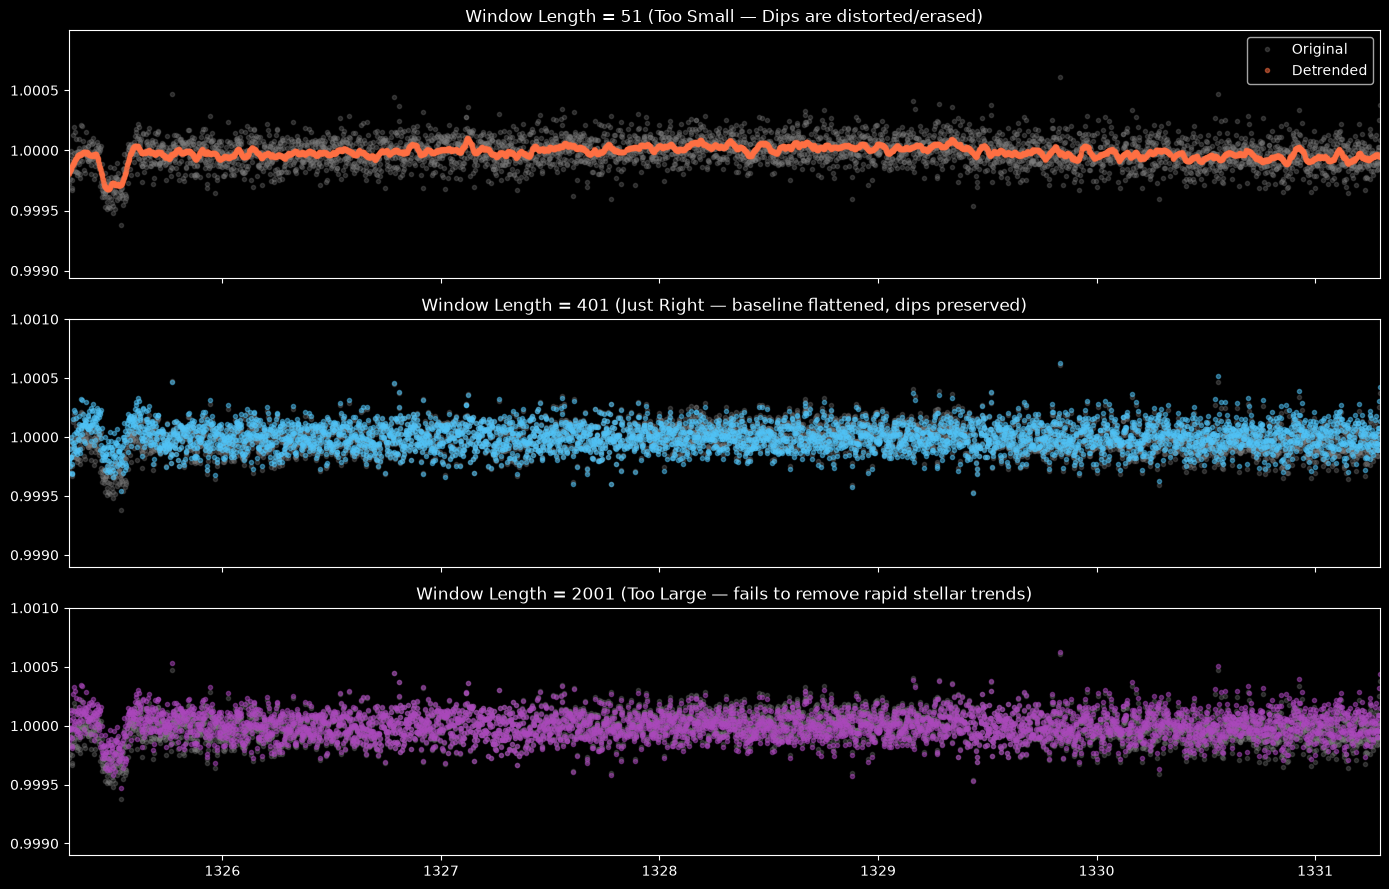

In [5]:
time = lc.time.value
flux = normalized_flux.copy()

# Interpolate NaNs to avoid filter errors
nans = np.isnan(flux)
x = np.arange(len(flux))
flux[nans] = np.interp(x[nans], x[~nans], flux[~nans])

# Try three different S-G window lengths
# (Remember, 2-min cadence means 720 points = 24 hours)
trend_small = lk.LightCurve(time=time, flux=flux).flatten(window_length=51).flux.value  # ~1.7 hours
trend_good  = detrend_savgol(flux, window_length=401)  # ~13.4 hours
trend_large = detrend_savgol(flux, window_length=2001)  # ~66 hours

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(time, flux, '.', color='grey', alpha=0.3, label='Original')
axes[0].plot(time, flux / trend_small, '.', color='#FF7043', alpha=0.5, label='Detrended')
axes[0].set_title("Window Length = 51 (Too Small — Dips are distorted/erased)")
axes[0].legend(loc='upper right')

axes[1].plot(time, flux, '.', color='grey', alpha=0.3)
axes[1].plot(time, trend_good, '.', color='#4FC3F7', alpha=0.5)
axes[1].set_title("Window Length = 401 (Just Right — baseline flattened, dips preserved)")

axes[2].plot(time, flux, '.', color='grey', alpha=0.3)
axes[2].plot(time, trend_large, '.', color='#AB47BC', alpha=0.5)
axes[2].set_title("Window Length = 2001 (Too Large — fails to remove rapid stellar trends)")

plt.xlim(time[0], time[0] + 6)  # look at first 6 days
plt.tight_layout()
plt.show()

---
## 📚 Concept 4: Phase Folding — Stacking the Transits

Individual transit dips are often buried in noise. However, if a planet orbits its star periodically, the transit repeats at exact intervals (the **Orbital Period**).

By folding the light curve at this period, we wrap time modulo the period:
$$\text{Phase} = \left( \frac{\text{Time} - t_0}{\text{Period}} \right) \pmod{1}$$

This aligns all transit events at Phase = 0, stacking them together. The random noise averages out, while the coherent transit signal stands out clearly! 
This increases the signal-to-noise ratio by a factor of approximately $\sqrt{N_{\text{transits}}}$.

### 🔬 Exercise: Visualising Phase-Folding
WASP-121b has a known orbital period of **1.2749 days** and a transit epoch $t_0$ of **2458325.7895 BTJD**.
Let's clean the light curve using our full pipeline and fold it!

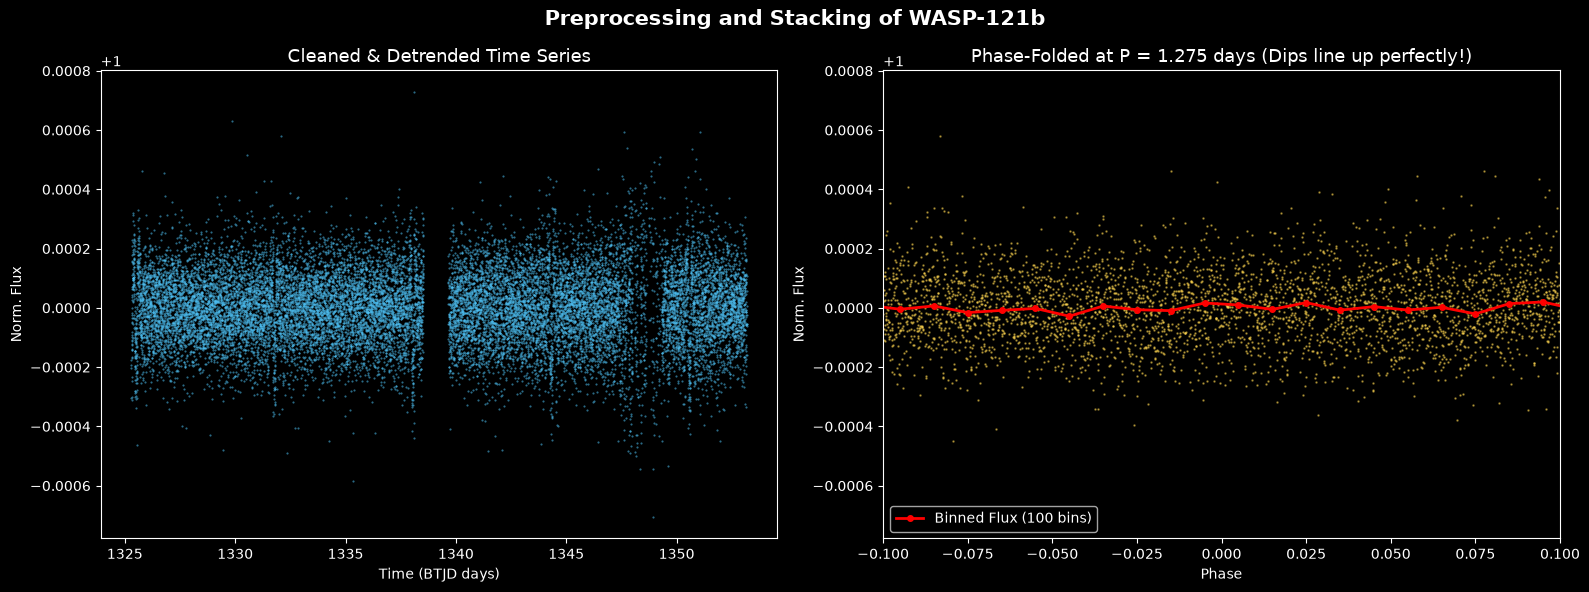

In [6]:
# 1. Run the entire preprocessing pipeline on our WASP-121 light curve
time_clean, flux_clean, error_clean = preprocess_lightcurve(lc, sigma_clip_threshold=5.0, window_length=401)

# 2. Known planet parameters
period_wasp121 = 1.274925
t0_wasp121     = 1325.7895  # adjusted to Sector 1 times

# 3. Phase fold
phase, folded_flux = fold_lightcurve(time_clean, flux_clean, period_wasp121, t0_wasp121)

# 4. Plot the results!
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Preprocessed light curve
axes[0].plot(time_clean, flux_clean, '.', color='#4FC3F7', ms=1.0, alpha=0.6)
axes[0].set_title("Cleaned & Detrended Time Series", fontsize=13)
axes[0].set_xlabel("Time (BTJD days)")
axes[0].set_ylabel("Norm. Flux")

# Right: Phase-folded light curve
axes[1].plot(phase, folded_flux, '.', color='#FFD54F', ms=1.5, alpha=0.5)
# Bin the folded data to show the shape even more clearly
bin_edges = np.linspace(-0.5, 0.5, 101)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
binned_flux = []
for i in range(len(bin_edges)-1):
    mask = (phase >= bin_edges[i]) & (phase < bin_edges[i+1])
    binned_flux.append(np.median(folded_flux[mask]))
axes[1].plot(bin_centers, binned_flux, 'o-', color='red', lw=2.0, ms=4.0, label='Binned Flux (100 bins)')

axes[1].set_title("Phase-Folded at P = 1.275 days (Dips line up perfectly!)", fontsize=13)
axes[1].set_xlabel("Phase")
axes[1].set_ylabel("Norm. Flux")
axes[1].set_xlim(-0.1, 0.1)  # Zoom in close to the transit dip
axes[1].legend(loc='lower left')

plt.suptitle("Preprocessing and Stacking of WASP-121b", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/figures/wasp121_folded.png", dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Notebook 02 Summary

**ML concepts learned:**
- **Systematics cleaning**: cleaning raw signals before inputting them to algorithms.
- **Normalisation**: putting inputs on a common, unit-less relative scale.
- **Robust statistics**: using the median over mean to isolate outliers without skewing statistics.
- **Frequency filtering**: using sliding-window filters to separate slow variations from fast fluctuations.
- **Signal stacking**: folding cyclic time series data to amplify weak, repeating signals.

**Astronomy concepts learned:**
- Quality flags and bitmask filtering
- Long-term stellar activity (rotation, spots) vs. orbital periods
- Transit depth measurements from folded light curves

**Next:** Notebook `03_bls_detection.ipynb` — finding these transit periods automatically using Box Least Squares (BLS)!